# Поиск инсайтов и точек роста

**Автор:** Ангелина Гольцева

**Дата:** 08.05.2026

### Введение

**Цель проекта** - поиск инсайтов, которые позволят сервису доставки еды повысить показатель удержания пользователей и улучшить взаимодействие с партнерами.

**Задачи проекта**

В рамках данного проекта проведен комплексный анализ данных:
- изучен пользовательский путь и конверсии через воронки;
- сегментированы пользователи с помощью RFM-модели для оценки лояльности и поведения клиентов;
- кластеризованы рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.

Такой подход позволит ближе познакомиться с работой сервиса, выявить узкие места и предложить решения для удержания пользователей и повышения эффективности сотрудничества с ресторанами.


### Данные

Данные включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.


## Загрузка данных и их предобработка

Загрузите данные и получите первую информацию о них. Проведите необходимую предобработку. Основную информацию о данных и этапы предобработки зафиксируйте в кратком промежуточном выводе.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
df.head()

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
0,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,authorization,2021-05-01 16:07:53,NaN,NaN,NaN,NaN,NaN,NaN
1,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,reg_page,2021-05-01 16:09:16,NaN,NaN,NaN,NaN,NaN,NaN
2,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,confirm_phone,2021-05-01 16:09:19,NaN,NaN,NaN,NaN,NaN,NaN
3,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,login,2021-05-01 16:09:23,NaN,NaN,NaN,NaN,NaN,NaN
4,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:34,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

In [7]:
df['user_id'] = df['user_id'].astype('int64')

**Обзор данных:**

Датасет содержит 205510 строк и 15 столбцов, типы данных в столбцах соответствуют содержащимся в них данным, кроме `user_id` - столбец содержит числовые идентификаторы пользователей, поэтому преобразован к типу `int64`. Данные в столбцах с датами `first_date` и `datetime` были приведены к корректному типу при импорте датасета.

Наименования столбцов соответствуют их содержимому и указаны в корректном стиле. Пропуски содержатся в столбцах `rest_id`,`object_id`,`order_id`,`revenue`,`delivery`,`comission` - это связано с тем, что данные заполняются для определенных типов событий.

---

## Анализ пользовательского пути

Маркетологи стали замечать следующее: деньги на рекламу по-прежнему тратятся, а заказов стало меньше. И это несмотря на то, что приложение скачивается и устанавливается так же активно, как раньше. Складывается ощущение, что пользователи где-то теряются. При этом доля заказов с десктопной версии приложения увеличилась по сравнению с мобильной.

Разработчики говорят, что последние обновления мобильной версии приложения не должны были повлиять на каталог блюд или его выбор для заказа и последующей оплаты доставки, так как изменения касались нового алгоритма подтверждения мобильного телефона и адреса доставки.

Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов:
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [8]:
funnel_steps = ['authorization','main_page','reg_page','confirm_phone','object_page','add_to_cart','order']

funnel_df = df[df['event'].isin(funnel_steps)]
funnel_df = funnel_df.groupby('event')['user_id'].nunique().reindex(funnel_steps).reset_index()
funnel_df = funnel_df.rename(columns={'user_id': 'n_users'})

funnel_df['classic_cr, %'] = round(100 * (funnel_df['n_users'] / funnel_df['n_users'].iloc[0]),2)
funnel_df['cr_previous_step, %'] = round(100 * (funnel_df['n_users'] / funnel_df['n_users'].shift(1)),2)

funnel_df

,event,n_users,"classic_cr, %","cr_previous_step, %"
0,authorization,7410,100.00,NaN
1,main_page,6537,88.22,88.22
2,reg_page,5417,73.10,82.87
3,confirm_phone,4190,56.55,77.35
4,object_page,3453,46.60,82.41
5,add_to_cart,2899,39.12,83.96
6,order,2416,32.60,83.34


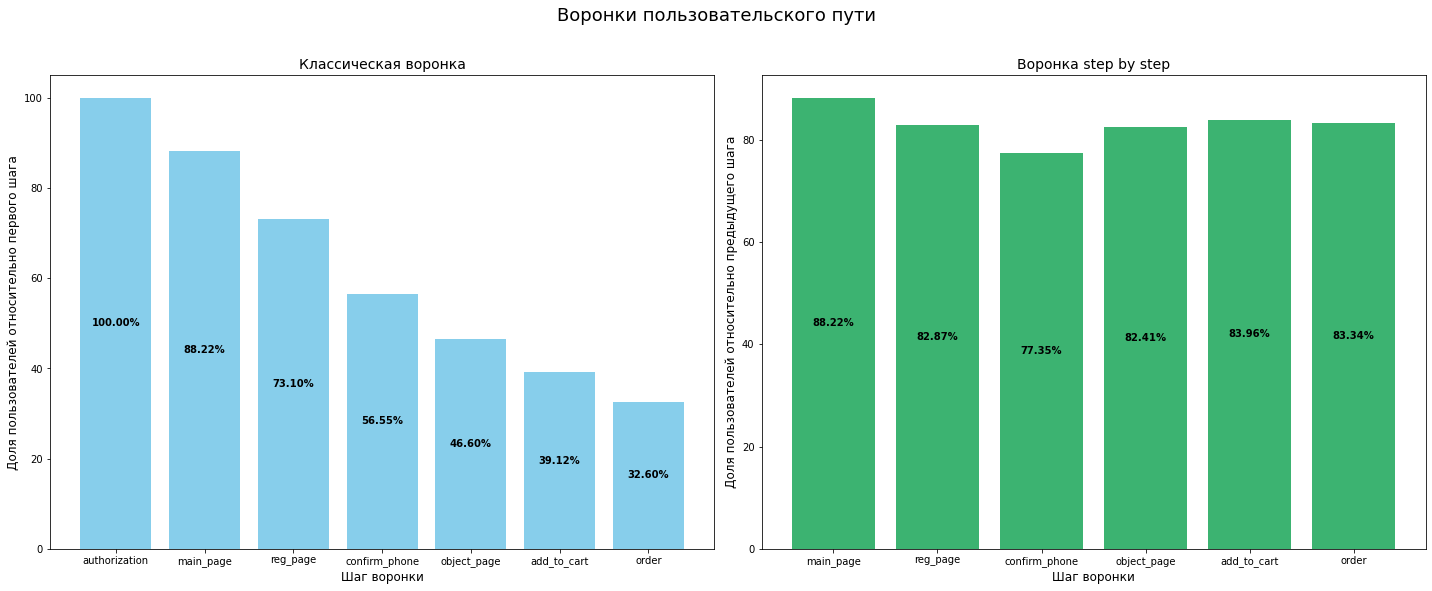

In [9]:
fig, axes = plt.subplots(1,2, figsize=(20, 8))

axes[0].bar(funnel_df['event'], funnel_df['classic_cr, %'], color='skyblue')
axes[0].set_title(f'Классическая воронка', fontsize=14)
axes[0].set_xlabel('Шаг воронки', fontsize=12)
axes[0].set_ylabel('Доля пользователей относительно первого шага', fontsize=12)

for patch in axes[0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        f'{height:.2f}%',
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

axes[1].bar(funnel_df['event'], funnel_df['cr_previous_step, %'], color='mediumseagreen')
axes[1].set_title(f'Воронка step by step', fontsize=14)
axes[1].set_xlabel('Шаг воронки', fontsize=12)
axes[1].set_ylabel('Доля пользователей относительно предыдущего шага', fontsize=12)


for patch in axes[1].patches:
    height = patch.get_height()
    if pd.isna(height):
        continue
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1].text(
        x,
        y,
        f'{height:.2f}%',
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )


plt.suptitle(f'Воронки пользовательского пути', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

**Пользовательский путь представлен 7 этапами** - авторизация пользователя и запуск приложения (`authorization`), загрузка основной страницы приложения (`main_page`), переход на страницу регистрации (`reg_page`), подтверждение телефона и окончание процесса регистрации (`confirm_phone`), переход на страница блюда (`object_page`), добавление блюда в корзину (`add_to_cart`), оформление заказа (`order`).

При составлении и визуализации воронок пути пользователя (классическая конверсия относительно первого шага и конверсия относительно предшествующего шага) выявлено, что наибольшее количество пользователей теряется на шаге подтверждения мобильного телефона - **почти половина пользователей**, запустивших приложение, не доходят до этого этапа (конверсия из `authorization` в `confirm_phone` составляет **56.55%**), и лишь **77.35% пользователей**, начавших регистрацию, подтверждают номер телефона. 

Таким образом, этап подтверждения мобильного телефона и завершения регистрации является *узким местом в воронке пользовательского пути*, что может быть связано с введением нового алгоритма подтверждения мобильного телефона в приложении.

----


#### Анализ пользовательского пути мобильной и десктопной версий приложения

In [10]:
df['device_type'].unique()

array(['Desktop', 'Mobile'], dtype=object)

In [11]:
desktop_df = df[df['device_type'] == 'Desktop']
counts_desktop = desktop_df[desktop_df['event'].isin(funnel_steps)]
counts_desktop_agg = counts_desktop.groupby('event')['user_id'].nunique().reindex(funnel_steps)
desktop_funnel = round(counts_desktop_agg / counts_desktop_agg.shift(1) * 100, 1)

mobile_df = df[df['device_type'] == 'Mobile']
counts_mobile = mobile_df[mobile_df['event'].isin(funnel_steps)]
counts_mobile_agg = counts_mobile.groupby('event')['user_id'].nunique().reindex(funnel_steps)
mobile_funnel = round(counts_mobile_agg / counts_mobile_agg.shift(1) * 100, 1)

funnel_compare = pd.DataFrame({
    'step': funnel_steps[1:],
    'desktop_cr, %': desktop_funnel[1:].values,
    'mobile_cr, %': mobile_funnel[1:].values
})

funnel_compare

,step,"desktop_cr, %","mobile_cr, %"
0,main_page,91.1,83.3
1,reg_page,79.4,88.4
2,confirm_phone,90.2,55.1
3,object_page,85.8,72.5
4,add_to_cart,82.9,86.7
5,order,82.3,85.8


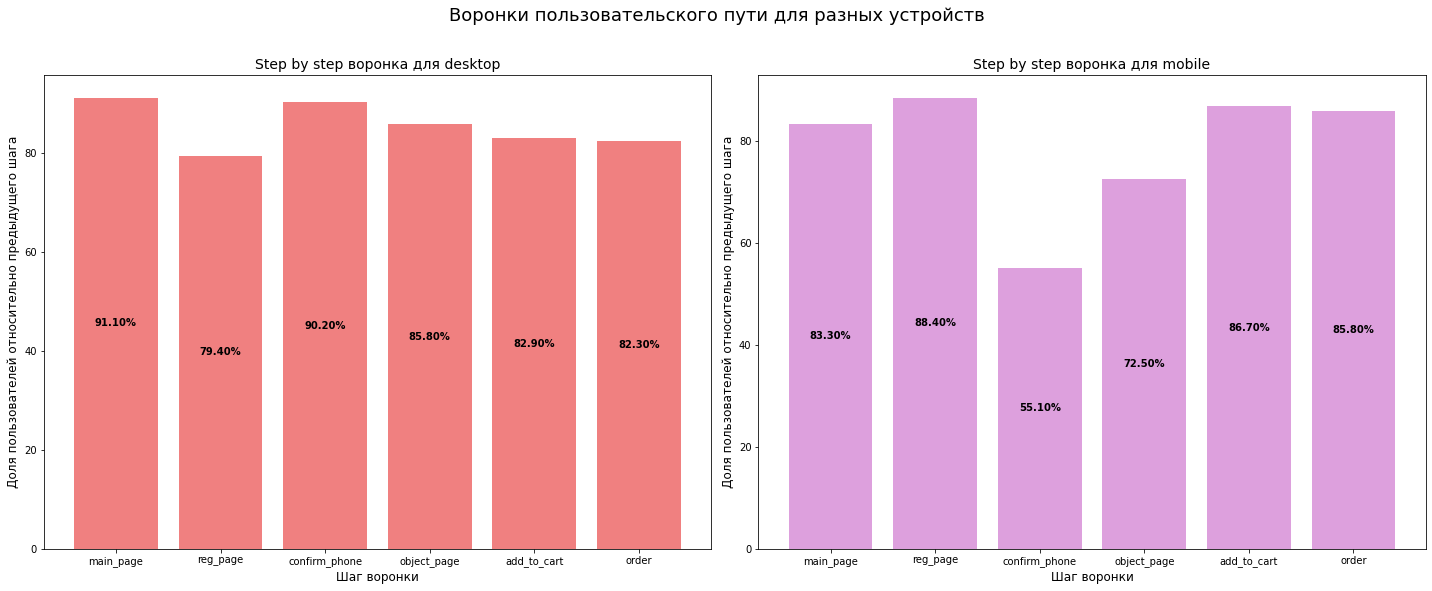

In [12]:
fig, axes = plt.subplots(1,2, figsize=(20, 8))

axes[0].bar(funnel_compare['step'], funnel_compare['desktop_cr, %'], color='lightcoral')
axes[0].set_title(f'Step by step воронка для desktop', fontsize=14)
axes[0].set_xlabel('Шаг воронки', fontsize=12)
axes[0].set_ylabel('Доля пользователей относительно предыдущего шага', fontsize=12)

for patch in axes[0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        f'{height:.2f}%',
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

axes[1].bar(funnel_compare['step'], funnel_compare['mobile_cr, %'], color='plum')
axes[1].set_title(f'Step by step воронка для mobile', fontsize=14)
axes[1].set_xlabel('Шаг воронки', fontsize=12)
axes[1].set_ylabel('Доля пользователей относительно предыдущего шага', fontsize=12)


for patch in axes[1].patches:
    height = patch.get_height()
    if pd.isna(height):
        continue
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1].text(
        x,
        y,
        f'{height:.2f}%',
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )


plt.suptitle(f'Воронки пользовательского пути для разных устройств', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

При построении и визуализации воронок step by step для пользователей мобильной и десктопной версий приложения выявлено, что при общих различиях конверсий по шагам не более 13.3% наблюдается явная проблема на этапе подтверждения мобильного телефона (`confirm_phone`) у пользователей *мобильной версии приложения* - лишь **55.1% пользователей, начавших регистрацию, подтверждают мобильный телефон**, в то время как у десктопной версии приложения этот шаг выполняют 90.2% пользователей. 

Это говорит о наличии проблем с алгоритмом подтверждения телефона именно в мобильной версии приложения, необходимо выяснить у команды разработки, есть ли баги на данном этапе.

---

## RFM сегментация

Для запуска рекламных кампаний, направленных на удержание платящих пользователей и их возврат в сервис, если они давно не совершали заказы произведу сегментирование пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трем показателям: 
- **давность** (Recency), 
- **частота покупок** (Frequency), 
- **сумма трат** (Monetary).

Дата анализа - **03 июля 2021 года**.

In [13]:
df_orders = df[df['event']=='order'].copy()

df_orders['recency'] = pd.to_datetime('2021-07-03') - df_orders['datetime']

df_rfm = df_orders.groupby('user_id').agg(  
    recency = ('recency', lambda x: x.min().days),
    frequency = ('datetime', 'count'),
    monetary = ('revenue', 'sum')
).reset_index()

df_rfm.head()

,user_id,recency,frequency,monetary
0,5506,32,2,3752.00
1,6291,57,1,1750.00
2,6820,41,1,1260.14
3,11062,57,1,3785.60
4,13254,54,1,553.00


In [14]:
df_rfm.describe()

,user_id,recency,frequency,monetary
count,2416.000000,2416.000000,2416.000000,2416.000000
mean,535932.551738,31.086093,1.468957,3720.171429
std,143745.266073,17.444239,0.950901,4036.352731
min,5506.000000,0.000000,1.000000,235.200000
25%,558738.250000,17.000000,1.000000,1512.000000
50%,591033.500000,29.000000,1.000000,2590.000000
75%,615221.000000,46.000000,2.000000,4443.117000
max,679837.000000,62.000000,12.000000,81690.000000


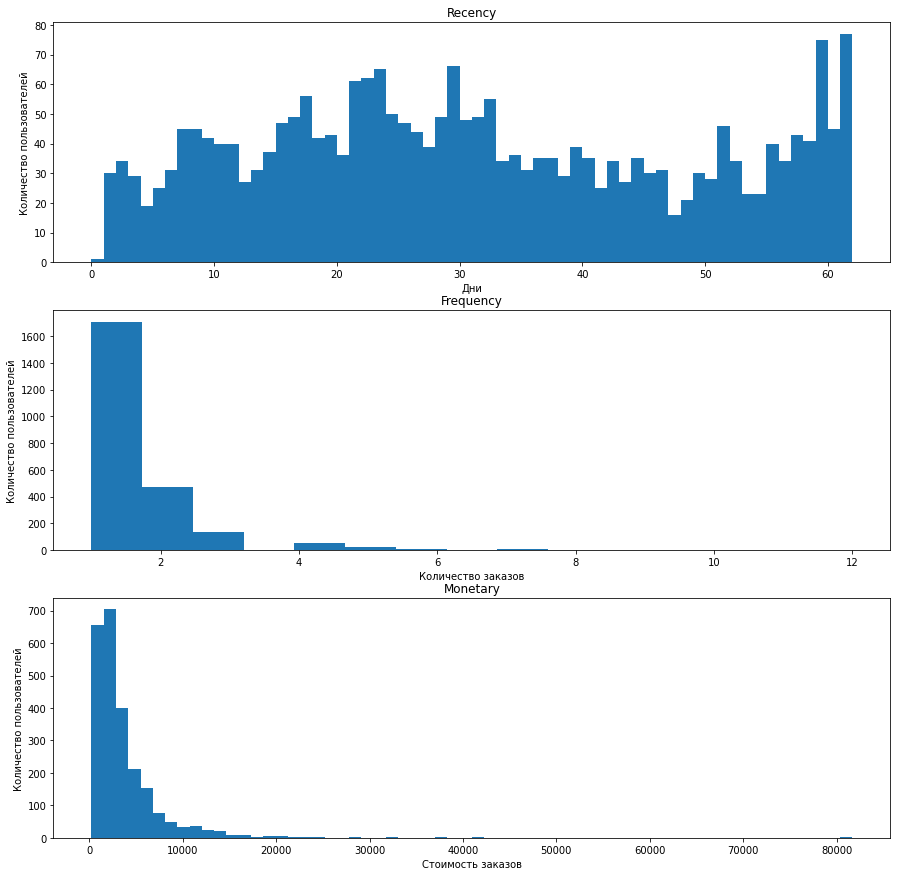

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].hist(df_rfm['recency'], bins=62)
axes[0].set_title('Recency')
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Количество пользователей')

axes[1].hist(df_rfm['frequency'], bins=15)
axes[1].set_title('Frequency')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

axes[2].hist(df_rfm['monetary'], bins=62)
axes[2].set_title('Monetary')
axes[2].set_xlabel('Стоимость заказов')
axes[2].set_ylabel('Количество пользователей')

plt.show()

На основании гистограмм по метрикам активности пользователей можно сказать следующее:

- Метрика **Recency** принимает широкий диапазон значений от 0 до 62 дней с момента последнего заказа. Пользователи совершали последние заказы почти равномерно на протяжении всего анализируемого периода. Это может быть связано с коротким окном наблюдения (описательная статистика данных покупателей показывает максимальную давность заказа 62 дня).

- Метрика **Frequency** визуализируется правоассимметричным распределением - основная часть пользователей делает 1-2 заказа, и только единицы заказывают более 10 раз, что может говорить о слабом удержании. 

- Метрика **Monetary** также показывает правоассиметриченое распределение с длинным хвостом, сформированным за счет единичных крупных заказов. Основная часть пользователей совершает небольшие заказы общей стоимостью до 3000 рублей.

#### Сегментация
    
Принципы выделения RFM сегментов:
- **Recency** — три равные группы.
- **Frequency** —  три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** — три группы по 33-му и 66-му перцентилям.

In [16]:
df_rfm['r'] = pd.qcut(df_rfm['recency'], q=3, labels=[3,2,1]) 
df_rfm['f'] = df_rfm['frequency'].apply(lambda x: 1 if x == 1 else (2 if x == 2 else 3))
df_rfm['m'] = pd.qcut(df_rfm['monetary'], q=3, labels=[1,2,3])

df_rfm[['r','f','m']] = df_rfm[['r','f','m']].astype('str')
df_rfm['rfm'] = df_rfm['r'] + df_rfm['f'] + df_rfm['m']

rfm_group = df_rfm.groupby('rfm').agg({'user_id':'nunique'}).reset_index().rename(columns={'user_id':'users'})

rfm_group['user_share'] = rfm_group['users'] / rfm_group['users'].sum()

rfm_group.sort_values(by='users', ascending=False)

,rfm,users,user_share
0,111,267,0.110513
17,311,258,0.106788
8,211,249,0.103063
1,112,233,0.096440
9,212,204,0.084437
18,312,202,0.083609
19,313,110,0.045530
10,213,104,0.043046
13,223,101,0.041805
22,323,97,0.040149


Наиболее многочисленная группа пользователей приложения доставки это пользователи с **RFM 111** (267 пользователей)- это самая малоценная аудитория с точки зрения вовлеченности и объемов трат. Далее в топе следуют пользователи с RFM 311 и 211 (258 и 249 пользователей соответственно) - они совершали заказы недавно, но тратили мало и нечасто. *Самые ценные для бизнеса пользователи (RFM 333) составляют лишь 3% от всех пользователей*, а польхователи, тратившие часто и много, но давно не посещавшие приложение (RFM 133) составляют 2% от всех.

**RFM-анализ показал**, что основная часть аудитории приложения имеет низкую вовлечённость и ценность для бизнеса, тогда как доля самых ценных пользователей остаётся небольшой. Это говорит о необходимости усиления механизмов удержания пользователей после первого заказа и возвращения неаткивных пользователей в продукт, однако тратить все усилия на развитие сегмент 111 не стоит.

- Наиболее перспективными для роста являются сегменты 311 и 211, поскольку они сохраняют недавнюю активность и могут быть возвращены относительно несложно. Рекомендуется внедрить для этой категории пользователей акции, стимулирующие повторные заказы - например бесплатная доставка или промокоды с ограниченным сроком действия. 

- Также внимание следует уделить сегменту 133 - ранее высокодоходным пользователям, которые перестали пользоваться сервисом. Их возвращение положительно скажется на динамике выручки и вовлеченности в продукт. Можно сделать коммуникацию с персональными предложениями.

- Важно сохранить самый ценный сегмент 333, это можно сделать с помощью специальной программы лояльности, приоритетного обслуживания в чатах поддержки и персонализированных акций.

---

## K-Means кластеризация

Чтобы лучше понимать поведение ресторанов и предлагать им персонализированные условия сотрудничества, а также создавать персонализированные предложения для пользователей, маркетологи запросили кластеризацию ресторанов по следующим параметрам:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

**Информация о ресторанах**

In [17]:
data = df.groupby('rest_id').agg({
    'order_id':'count','revenue':'mean','object_id':'nunique'
}).reset_index().rename(columns={
    'order_id':'n_orders','revenue':'mean_revenue','object_id':'unique_dishes'})
cluster_data = data[['n_orders','mean_revenue','unique_dishes']].copy()

cluster_data.head(10)

,n_orders,mean_revenue,unique_dishes
0,290,2385.644897,46
1,204,2984.793137,37
2,15,2050.570667,10
3,68,2694.695294,4
4,68,2019.813353,11
5,89,3271.897843,10
6,233,3056.845923,20
7,14,2574.000000,11
8,1992,2676.025432,159
9,12,4890.666667,7


**Нормализация данных и поиск оптимального числа кластеров**

In [18]:
scaler = StandardScaler()

cluster_norm = scaler.fit_transform(cluster_data)

for k in range(2, 10):
   km = KMeans(n_clusters=k)
   km.fit(cluster_norm)
   print("Суммарное внутрикластерное расстояние при", k, "кластерах равно: ", km.inertia_)

Суммарное внутрикластерное расстояние при 2 кластерах равно:  23.178787457790772
Суммарное внутрикластерное расстояние при 3 кластерах равно:  8.993114231683709
Суммарное внутрикластерное расстояние при 4 кластерах равно:  4.093360331119286
Суммарное внутрикластерное расстояние при 5 кластерах равно:  3.0364126365766566
Суммарное внутрикластерное расстояние при 6 кластерах равно:  2.006654741932407
Суммарное внутрикластерное расстояние при 7 кластерах равно:  1.5380216453045625
Суммарное внутрикластерное расстояние при 8 кластерах равно:  1.2362271371000297
Суммарное внутрикластерное расстояние при 9 кластерах равно:  0.9717786540300191


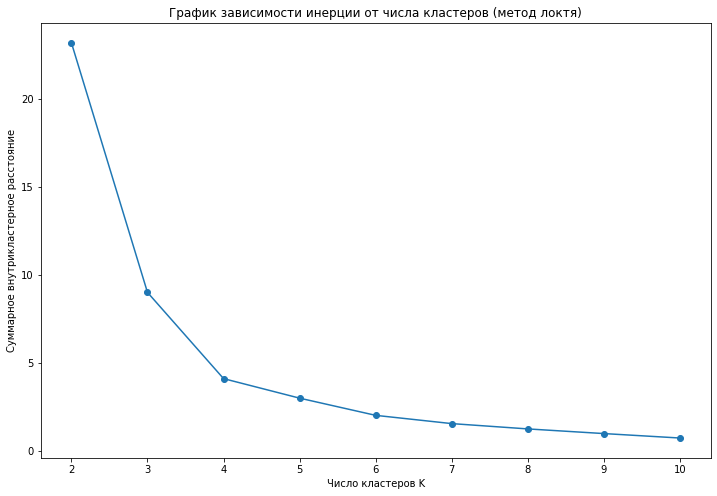

In [19]:
i = []

min_k = 2
max_k = 10

plt.figure(figsize=(12, 8))

for k in range(min_k, max_k + 1):
   km = KMeans(n_clusters=k)
   km.fit_transform(cluster_norm)
   i.append(km.inertia_)

plt.plot(range(min_k, max_k + 1), i, marker='o')
plt.xlabel('Число кластеров K')
plt.ylabel('Суммарное внутрикластерное расстояние')
plt.title('График зависимости инерции от числа кластеров (метод локтя)')
plt.show()

На графике выше видно, что скорость уменьшения суммарного внутрикластерного расстояния снижается после 4 кластера, поэтому разумным видится деление данных **на 4 кластера**.

**Кластеризация**

In [20]:
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(cluster_norm)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 0])
sorted_centroids = centroids[sorted_indices]

centroids_df = pd.DataFrame(
   sorted_centroids,
   columns=['Количество заказов', 'Средний чек', 'Уникальных блюд'],
   index=[f'Кластер {i + 1}' for i in range(kmeans.n_clusters)]
)

pd.options.display.float_format = '{:.3f}'.format

centroids_df

,Количество заказов,Средний чек,Уникальных блюд
Кластер 1,135.333,1844.668,12.778
Кластер 2,141.250,2854.574,18.625
Кластер 3,162.500,4693.617,8.000
Кластер 4,2167.500,2490.467,161.500


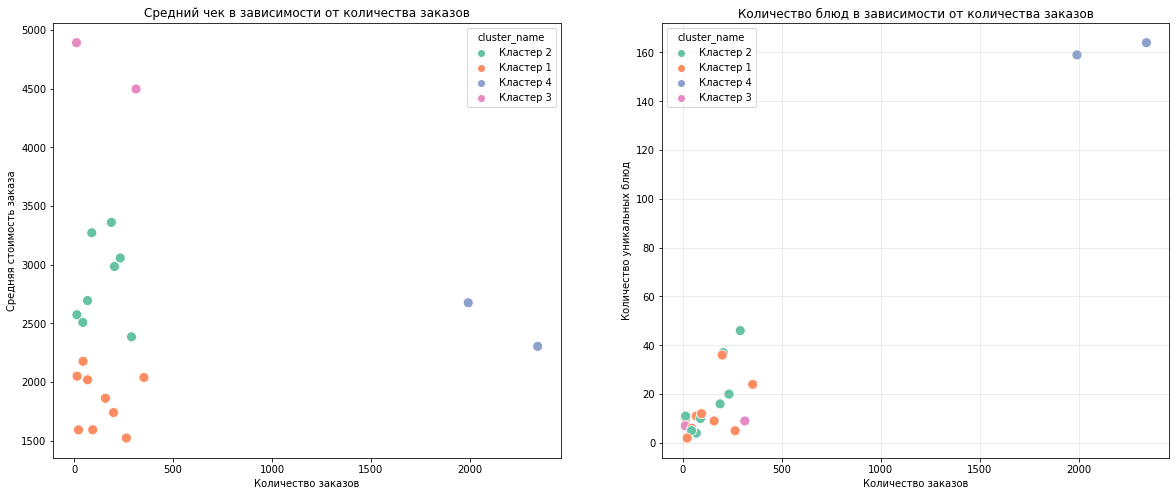

In [21]:
cluster_data['cluster'] = labels
cluster_names = {
    old_cluster: centroids_df.index[new_cluster]
    for new_cluster, old_cluster in enumerate(sorted_indices)
}
cluster_data['cluster_name'] = (cluster_data['cluster'].map(cluster_names))

fig, axes = plt.subplots(1,2, figsize=(20, 8))

sns.scatterplot(data=cluster_data,
    x='n_orders',
    y='mean_revenue',
    hue='cluster_name',
    ax = axes[0],
    palette='Set2',
    s=100
)
axes[0].set_title('Средний чек в зависимости от количества заказов')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Средняя стоимость заказа')

sns.scatterplot(data=cluster_data,
    x='n_orders',
    y='unique_dishes',
    hue='cluster_name',
    ax = axes[1],
    palette='Set2',
    s=100
)

axes[1].set_title('Количество блюд в зависимости от количества заказов')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество уникальных блюд')
plt.grid(alpha=0.3)

plt.show()

В процессе кластеризации ресторанов были выделены 4 кластера по количеству заказов, среднему чеку и ассортименту блюд.

- Кластер 1 представлен ресторанами с небольшим средним чеком и малым ассортиментом. Возожно это небольшие кафе в спальных районах.
- Кластер 2 состоит из заведений чуть побольше, где шире ассортимент и выше средняя стоиомсть заказа.
- Кластер 3 представляют рестораны с самым маленьким ассортиментом блюд из всех, но с самым высоким средним чеком. Это единичные рестораны премиум-класса с высокой стоимостью блюд.
- Кластер 4 значительно выделяется среди остальных по количеству заказов - разница более чем в 10 раз. Также рестораны этого кластера отличаются наиболее широким ассортиментом блюд. Это массовые заведения по типу фаст-фуд или сетевые заведения.

На диаграммах рассеяния видно, что кластеры 1 и 2 находятся примерно в одном диапазоне по соотношению средней стоимости к количеству заказов, а кластеры 3 и 4 выделяются по стоимости заказа и количеству заказов соответственно. На диаграмме отношения ассортимента ресторана к количеству заказов явно выделяется только кластер 4, показывающий высокие средние значения по обоим параметрам.

---

## Итоговый вывод и рекомендации

**Целью исследования** является поиск инсайтов, которые позволят сервису доставки еды повысить показатель удержания пользователей и улучшить взаимодействие с партнерами.

В рамках исследования был использован датасет с информацией о пользовательских событиях, включающих в себя информацию о версиях приложения, заказах и ресторанах, где были сделаны заказы. 

**Были выполнены следующие задачи:**
- Выполнена загрузка данных и их предобработка.
- Произведен анализ пользовательского пути и воронки взаимодействия пользователей с продуктом.
- Произведена RFM сегментация пользователей, выявлены наиболее перспективные для развития сегменты.
- Для выявления структуры ресторанов в сервисе выполнена K-Means кластеризация, в рамках которой были выделены 4 кластера ресторанов в зависимости от количества заказов, среднего чека и ассортимента блюд.
- Сформулированы промежуточные выводы, итоговый вывод и рекомендации для бизнеса.

#### Общий вывод 

Анализ пользовательского поведения, воронки взаимодействия пользователей с продуктом, RFM-сегментации и структуры ресторанов показал, что ключевая проблема сервиса заключается не в привлечении пользователей или разнообразии предложения, а в удержании и конверсии на ранних этапах жизненного цикла пользователя, особенно в процессе регистрации.

**Воронка взаимодействия с продуктом**

Пользовательский путь представлен 7 этапами от авторизации до оформления заказа. При составлении и визуализации воронок пути пользователя (классическая конверсия относительно первого шага и конверсия относительно предшествующего шага) выявлено, что этап подтверждения мобильного телефона и завершения регистрации в мобильной версии приложения является узким местом в воронке пользовательского пути, что может быть связано с введением нового алгоритма подтверждения мобильного телефона в мобильной версии приложении. 

**Пользовательское поведение**

Основная часть аудитории приложения имеет низкую вовлечённость и ценность для бизнеса, тогда как доля самых ценных пользователей остаётся небольшой. Это говорит о необходимости усиления механизмов удержания пользователей после первого заказа и возвращения неаткивных пользователей в продукт, а также реактивации спящих "китов" и удержании активных "китов".

**Рестораны-партнеры**

Рестораны можно разделить на 4 кластера:

- Маленькие кафе с низким чеком и небольшим ассортиментом
- Средние заведения с умеренными показателями
- Премиум-рестораны с высоким чеком и маленьким меню
- Массовые сетевые/фаст-фуд с большим потоком заказов и широким ассортиментом

Основной вклад в количество заказов дают именно массовые сетевые рестораны, тогда как премиум-сегмент формирует выручку через высокий чек. Кластеры 1 и 2 находятся в схожей зоне и могут рассматриваться как базовый массовый сегмент.

#### Рекомендации

1. Необходимо в первую очередь **устранить узкое место в воронке** - исправить возможный баг на этапе подтверждения телефона в мобильной версии приложения.
2. **Разработать стратегии удержания** новых, но малоактивных пользователей через временные акции, направленные на стимулирование к повторным заказам. Также важно поработать с программой лояльности, позволяющей удержать ценный сегмент наиболее активных и прибыльных клиентов, и персональными реактивационными предложениями, возвращающими ушедших клиетов, которые были ранее активны и приносили большой доход сервису.
3. При работе с ресторанами-партнерами необходимо **найти подход, снижающий зависимость** от одного кластера ресторанов (массовые с большой выручкой). Можно усилить базу кластеров 1 и 2 (небольшие и средние рестораны с умеренным потоком), стимулируя заказы именно там, а с помощью премиум-ресторанов стимулировать рост выручки, усиливая их видимость по особым поводам (например, праздники, банкеты и т.п.)